# Beyond the Tarmac: Predicting Airline Delay Causes

**Name:** Shreyon Roy, Crystal Zhang, Dorien Zhang \
**NetID's:** sr5655, cz3150, dxz207\
CSGY 6513 Big Data Spring 2026 \
Final Project

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('airline_delay_cleaned2.csv')

df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2025,11,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",87.0,15.0,3.66,1.71,...,0.0,6.40,7.0,0.0,1001.0,132.0,114.0,112.0,0.0,643.0
1,2025,11,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",22.0,6.0,4.18,0.04,...,0.0,1.27,2.0,0.0,792.0,569.0,7.0,16.0,0.0,200.0
2,2025,11,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",87.0,15.0,8.44,1.00,...,0.0,4.19,7.0,0.0,905.0,408.0,119.0,46.0,0.0,332.0
3,2025,11,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",58.0,14.0,7.13,0.00,...,0.0,5.39,5.0,0.0,752.0,356.0,0.0,90.0,0.0,306.0
4,2025,11,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",56.0,20.0,3.92,0.00,...,0.0,9.67,1.0,0.0,1654.0,439.0,0.0,316.0,0.0,899.0


In [2]:
# Load the dataset 
df = pd.read_csv('airline_delay_cleaned2.csv')

# Display dataset dimensions and initial structure
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn data types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())

# List of columns that must be numeric
numeric_cols = [
    'year', 'month', 'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct',
    'nas_ct', 'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted',
    'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay',
    'late_aircraft_delay'
]

# Convert each column to numeric, turning non‑convertible values into NaN
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Replace any remaining NaN in numeric columns with 0
df[numeric_cols] = df[numeric_cols].fillna(0)

# Fill missing string fields with a placeholder
df['carrier_name'] = df['carrier_name'].fillna('Unknown')
df['airport_name'] = df['airport_name'].fillna('Unknown')

# Map numeric month to abbreviated name
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
df['month_name'] = df['month'].map(month_names)

# Sum of the five individual delay causes
df['total_delay_causes'] = (df['carrier_delay'] + df['weather_delay'] +
                            df['nas_delay'] + df['security_delay'] +
                            df['late_aircraft_delay'])

# Verify that the reported total delay matches the sum of causes
diff = (df['arr_delay'] - df['total_delay_causes']).abs()
print("\nConsistency check: arr_delay vs sum of causes")
print(f"Max absolute difference: {diff.max():.2f} minutes")

# Compute percentage of flights delayed (where flights > 0)
df['pct_delayed'] = np.where(df['arr_flights'] > 0,
                              df['arr_del15'] / df['arr_flights'] * 100,
                              0)

# Compute average delay minutes per flight (where flights > 0)
df['avg_delay_min_per_flight'] = np.where(df['arr_flights'] > 0,
                                           df['arr_delay'] / df['arr_flights'],
                                           0)

# Extract two‑letter state abbreviation from the airport name (e.g. ", CA :")
def extract_state(airport_name):
    if pd.isna(airport_name):
        return None
    import re
    match = re.search(r',\s*([A-Z]{2})\s*:', str(airport_name))
    return match.group(1) if match else None

# Apply extraction to create a state column
df['state'] = df['airport_name'].apply(extract_state)

# Print overall summary statistics
print("\nSUMMARY:")
print(f"Total rows: {len(df)}")
print(f"Years covered: {df['year'].min()} – {df['year'].max()}")
print(f"Unique carriers: {df['carrier_name'].nunique()}")
print(f"Unique airports: {df['airport_name'].nunique()}")
print(f"Rows with missing state: {df['state'].isna().sum()}")

# Show a sample of the newly derived columns
print("\nSample of derived columns:")
print(df[['year', 'month_name', 'carrier_name', 'arr_delay', 
          'pct_delayed', 'avg_delay_min_per_flight', 'state']].head(10))

# Create aggregated table by carrier: total flights, delay minutes, delayed count, mean pct delayed
carrier_summary = df.groupby('carrier_name').agg({
    'arr_flights': 'sum',
    'arr_delay': 'sum',
    'arr_del15': 'sum',
    'pct_delayed': 'mean'
}).reset_index()

# Create aggregated table by airport: total flights, delay minutes, and first (only) state
airport_summary = df.groupby('airport_name').agg({
    'arr_flights': 'sum',
    'arr_delay': 'sum',
    'state': 'first'
}).reset_index()

Dataset shape: (416462, 21)

First 5 rows:
   year  month carrier       carrier_name airport  \
0  2025     11      9E  Endeavor Air Inc.     ABE   
1  2025     11      9E  Endeavor Air Inc.     ABY   
2  2025     11      9E  Endeavor Air Inc.     AEX   
3  2025     11      9E  Endeavor Air Inc.     AGS   
4  2025     11      9E  Endeavor Air Inc.     ALB   

                                        airport_name  arr_flights  arr_del15  \
0  Allentown/Bethlehem/Easton, PA: Lehigh Valley ...         87.0       15.0   
1             Albany, GA: Southwest Georgia Regional         22.0        6.0   
2           Alexandria, LA: Alexandria International         87.0       15.0   
3        Augusta, GA: Augusta Regional at Bush Field         58.0       14.0   
4                   Albany, NY: Albany International         56.0       20.0   

   carrier_ct  weather_ct  ...  security_ct  late_aircraft_ct  arr_cancelled  \
0        3.66        1.71  ...          0.0              6.40            7.0 

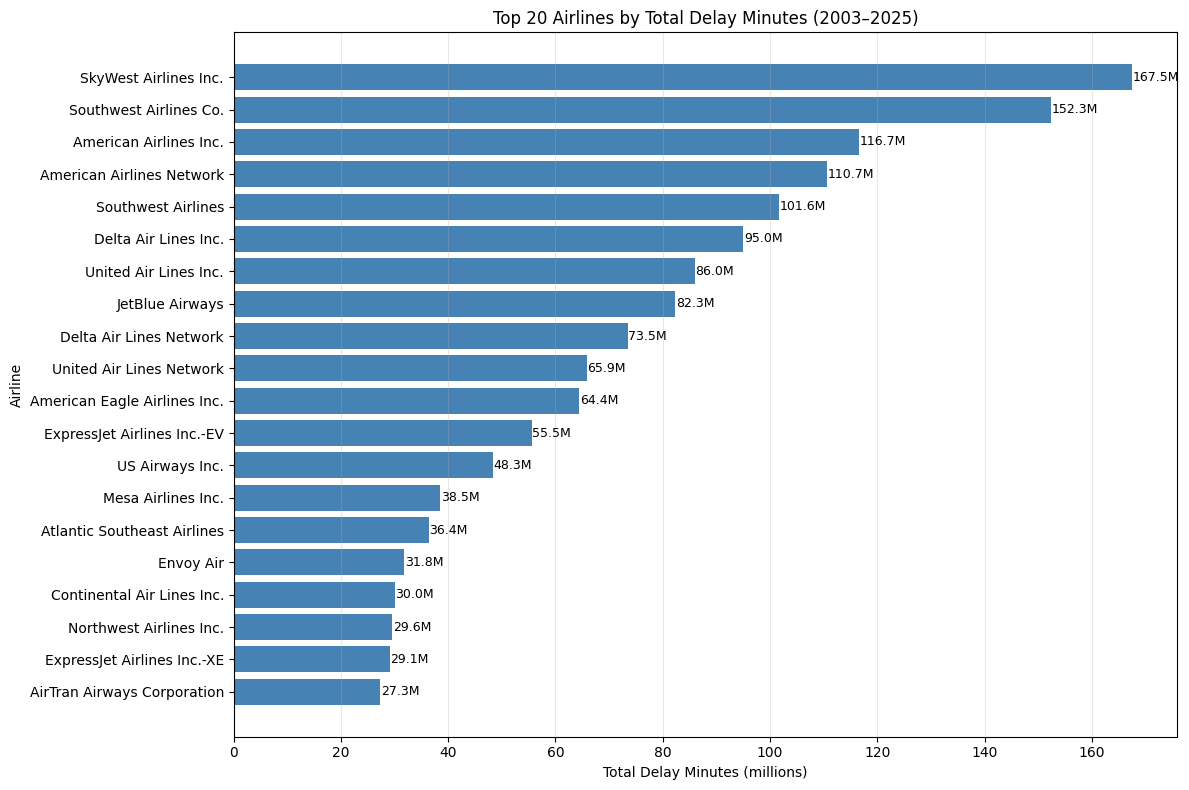

In [8]:
# Group by carrier and sum arrival delay minutes
carrier_delays = df.groupby('carrier_name')['arr_delay'].sum().reset_index()
# Sort descending so the worst airlines are at the top
carrier_delays = carrier_delays.sort_values('arr_delay', ascending=False)

# Keep only the top 20 carriers for the chart
top_n = 20
top_carriers = carrier_delays.head(top_n)

# Set up the figure and horizontal bar chart
plt.figure(figsize=(12, 8))
bars = plt.barh(top_carriers['carrier_name'], top_carriers['arr_delay'] / 1e6, color='steelblue')
plt.xlabel('Total Delay Minutes (millions)')
plt.ylabel('Airline')
plt.title(f'Top {top_n} Airlines by Total Delay Minutes (2003–2025)')
plt.gca().invert_yaxis()  # highest value at top

# Add value labels at the end of each bar (in millions)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2, f'{width:.1f}M', 
             va='center', ha='left', fontsize=9)

# Light grid lines for readability
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

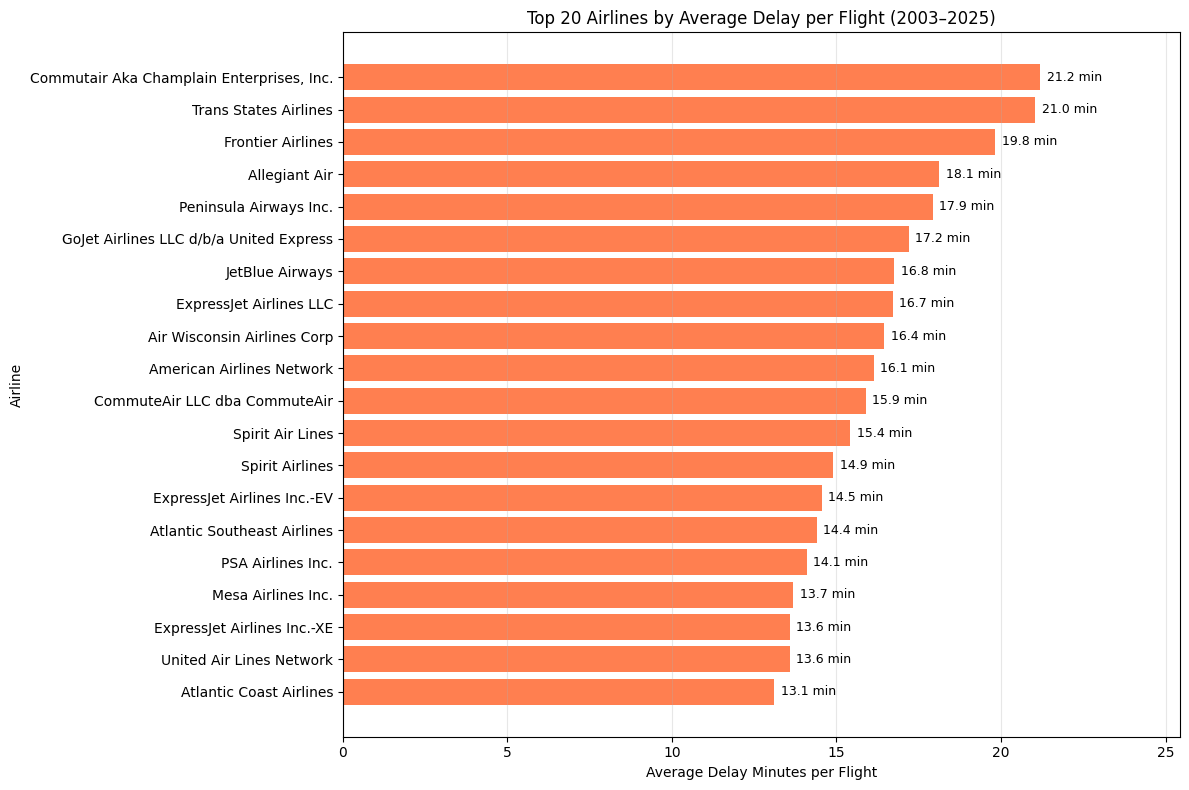

In [9]:
# Bar chart but normalized: show average delay per flight instead of total delay
# Aggregate total delay and total flights per carrier
carrier_stats = df.groupby('carrier_name').agg({
    'arr_delay': 'sum',
    'arr_flights': 'sum'
}).reset_index()

# Calculate average delay per flight; replace 0 flights with NaN to avoid division by zero
carrier_stats['avg_delay_per_flight'] = carrier_stats['arr_delay'] / carrier_stats['arr_flights'].replace(0, np.nan)

# Remove carriers with missing averages (e.g. no flights)
carrier_stats = carrier_stats.dropna(subset=['avg_delay_per_flight'])

# Select the top 20 carriers sorted by highest average delay per flight
top_carriers = carrier_stats.sort_values('avg_delay_per_flight', ascending=False).head(20)

# Horizontal bar chart
plt.figure(figsize=(12, 8))
bars = plt.barh(top_carriers['carrier_name'], top_carriers['avg_delay_per_flight'], color='coral')
plt.xlabel('Average Delay Minutes per Flight')
plt.ylabel('Airline')
plt.title('Top 20 Airlines by Average Delay per Flight (2003–2025)')
plt.gca().invert_yaxis()  # highest first

# Add value labels on each bar (minutes)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.2, bar.get_y() + bar.get_height()/2, f'{width:.1f} min', 
             va='center', ha='left', fontsize=9)

# Styling: grid, extra margin for labels, and adjust left margin for long carrier names
plt.grid(axis='x', alpha=0.3)
plt.margins(x=0.2)                     
plt.subplots_adjust(left=0.3)          
plt.tight_layout()
plt.show()

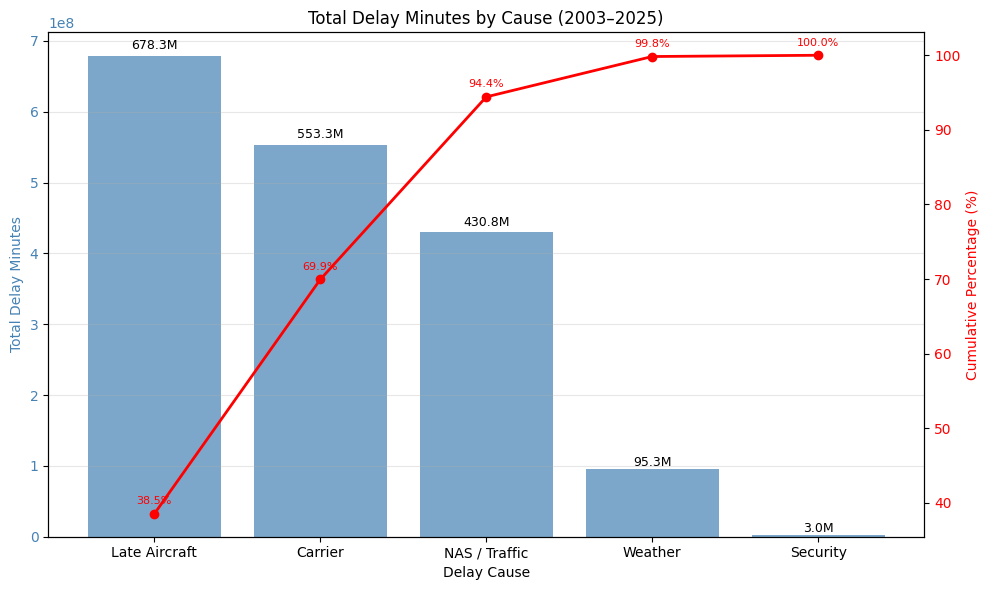

In [10]:
# Pareto Chart: bar chart of total delay by cause + cumulative percentage line
# Columns containing individual delay causes
cause_cols = ['carrier_delay', 'weather_delay', 'nas_delay', 'late_aircraft_delay', 'security_delay']
cause_labels = ['Carrier', 'Weather', 'NAS / Traffic', 'Late Aircraft', 'Security']

# Total minutes for each cause across all rows
cause_totals = df[cause_cols].sum().values

# Create a DataFrame sorted from largest to smallest cause
cause_df = pd.DataFrame({'cause': cause_labels, 'minutes': cause_totals})
cause_df = cause_df.sort_values('minutes', ascending=False)

# Compute cumulative percentage for the line plot
cause_df['cum_percent'] = cause_df['minutes'].cumsum() / cause_df['minutes'].sum() * 100

# Set up primary axis for bars
fig, ax1 = plt.subplots(figsize=(10, 6))

# Draw the bars (primary axis)
bars = ax1.bar(cause_df['cause'], cause_df['minutes'], color='steelblue', alpha=0.7)
ax1.set_xlabel('Delay Cause')
ax1.set_ylabel('Total Delay Minutes', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.grid(axis='y', alpha=0.3)

# Create secondary axis and plot cumulative percentage line
ax2 = ax1.twinx()
ax2.plot(cause_df['cause'], cause_df['cum_percent'], color='red', marker='o', linewidth=2, markersize=6)
ax2.set_ylabel('Cumulative Percentage (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# value labels: display total minutes in millions above each bar
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01*height,
             f'{height/1e6:.1f}M', ha='center', va='bottom', fontsize=9)

# % labels: cumulative percentage next to each point
for i, (x, y) in enumerate(zip(cause_df['cause'], cause_df['cum_percent'])):
    ax2.text(i, y + 1, f'{y:.1f}%', ha='center', va='bottom', fontsize=8, color='red')

# Title and final layout
plt.title('Total Delay Minutes by Cause (2003–2025)')
plt.tight_layout()
plt.show()

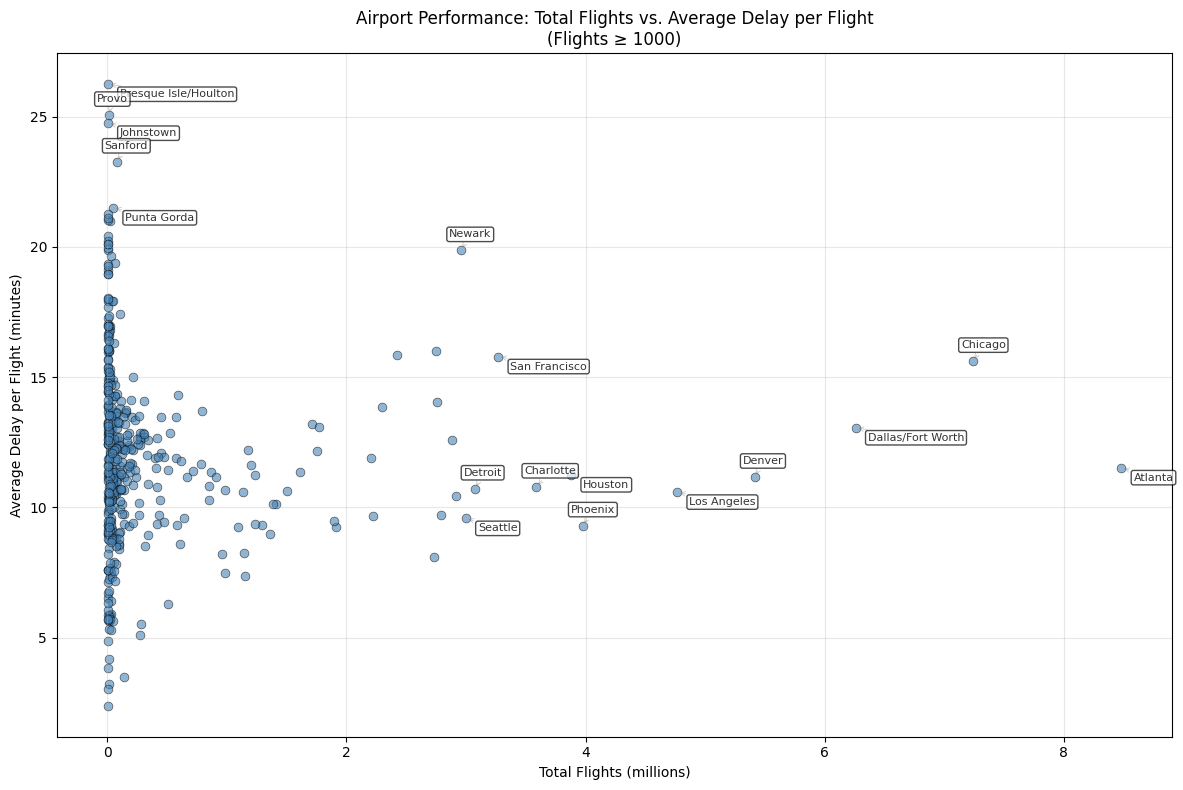

In [11]:
# Aggregate total flights and total delay per airport
airport_stats = df.groupby('airport_name').agg({
    'arr_flights': 'sum',
    'arr_delay': 'sum'
}).reset_index()

# Compute average delay per flight; replace 0 flights with NaN to avoid division by zero
airport_stats['avg_delay_per_flight'] = airport_stats['arr_delay'] / airport_stats['arr_flights'].replace(0, np.nan)
# Drop airports with no flights (or NaN average)
airport_stats = airport_stats.dropna(subset=['avg_delay_per_flight'])

# Filter to airports with at least a minimum number of flights (to exclude tiny airstrips)
min_flights = 1000
airport_stats = airport_stats[airport_stats['arr_flights'] >= min_flights]

# Create scatter plot of total flights (x) vs. average delay per flight (y)
plt.figure(figsize=(12, 8))
plt.scatter(airport_stats['arr_flights'] / 1e6, 
            airport_stats['avg_delay_per_flight'], 
            alpha=0.6, s=40, c='steelblue', edgecolors='black', linewidth=0.5)

# Select the top 12 airports by flight volume and top 5 by delay to label as outliers
top_flights = airport_stats.nlargest(12, 'arr_flights')
top_delays = airport_stats.nlargest(5, 'avg_delay_per_flight')
airports_to_label = pd.concat([top_flights, top_delays]).drop_duplicates(subset='airport_name')

# Annotate each selected airport with a short label and a simple alternating offset
for i, (_, row) in enumerate(airports_to_label.iterrows()):
    x = row['arr_flights'] / 1e6
    y = row['avg_delay_per_flight']
    # Alternate offset direction to reduce label overlap
    if i % 2 == 0:
        offset_x = 0.1
        offset_y = -0.5
    else:
        offset_x = -0.1
        offset_y = 0.5
    plt.annotate(row['airport_name'].split(',')[0][:20],  # shortened name (first part, max 20 chars)
                 xy=(x, y),
                 xytext=(x + offset_x, y + offset_y),
                 fontsize=8,
                 alpha=0.8,
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7),
                 arrowprops=dict(arrowstyle='->', color='gray', lw=0.5, alpha=0.5))

# Axis labels, title, grid, and layout
plt.xlabel('Total Flights (millions)')
plt.ylabel('Average Delay per Flight (minutes)')
plt.title(f'Airport Performance: Total Flights vs. Average Delay per Flight\n(Flights ≥ {min_flights})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()